
TASK 15: PART A & B – MODEL PERSISTENCE THEORY (PICKLE VS JOBLIB)
1. Model Persistence: The process of serializing a trained machine learning model 
   into a binary file so it can be saved to disk, reloaded, and deployed for inference 
   without re-training.
2. Pickle: Python's standard built-in serialization module. Great for general objects.
3. Joblib: Optimized specifically for Python objects containing large NumPy arrays 
   (e.g., Scikit-learn estimators). It provides faster disk I/O and efficient memory mapping.
4. When to Use Which:
   - Use Joblib when working with large Scikit-Learn models, Random Forests, or heavy arrays.
   - Use Pickle for lightweight native Python structures or simple models when external dependencies 
     are restricted.

TASK 15: PART C & D – END-TO-END MINI-PROJECT PIPELINE
- Dataset: Simulated Medical Risk Assessment (Heart Disease Risk)
- Features: 'Age', 'Resting_BP', 'Cholesterol', 'Max_Heart_Rate'
- Target: 'Heart_Disease_Risk' (1 = High Risk, 

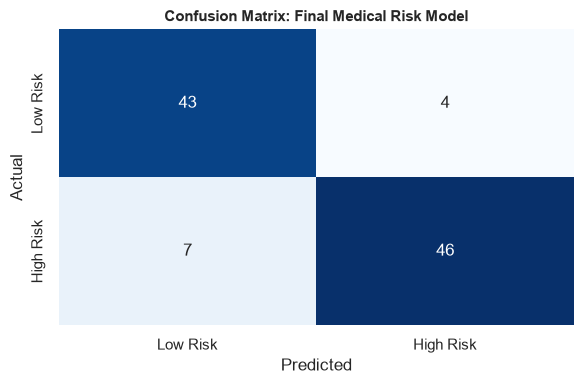

--- [Step 4] Persisting Final Production Artifacts ---
Saved 'final_medical_risk_model.joblib' and 'final_scaler.joblib' successfully to disk!


In [1]:
# =====================================================================
# PARTS A, B, C & D: THEORETICAL BREAKDOWN & DOCUMENTATION
# =====================================================================
print("""
===================================================================
TASK 15: PART A & B – MODEL PERSISTENCE THEORY (PICKLE VS JOBLIB)
===================================================================
1. Model Persistence: The process of serializing a trained machine learning model 
   into a binary file so it can be saved to disk, reloaded, and deployed for inference 
   without re-training.
2. Pickle: Python's standard built-in serialization module. Great for general objects.
3. Joblib: Optimized specifically for Python objects containing large NumPy arrays 
   (e.g., Scikit-learn estimators). It provides faster disk I/O and efficient memory mapping.
4. When to Use Which:
   - Use Joblib when working with large Scikit-Learn models, Random Forests, or heavy arrays.
   - Use Pickle for lightweight native Python structures or simple models when external dependencies 
     are restricted.

===================================================================
TASK 15: PART C & D – END-TO-END MINI-PROJECT PIPELINE
===================================================================
- Dataset: Simulated Medical Risk Assessment (Heart Disease Risk)
- Features: 'Age', 'Resting_BP', 'Cholesterol', 'Max_Heart_Rate'
- Target: 'Heart_Disease_Risk' (1 = High Risk, 0 = Low Risk)
- Pipeline: EDA -> Imputation -> Standard Scaling -> Model Training -> Persistence
""")

# =====================================================================
# SYSTEM CODE IMPLEMENTATION 
# =====================================================================
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Setup
sns.set_theme(style="whitegrid")
np.random.seed(42)

# ---------------------------------------------------------------------
# PART A & B: DEMONSTRATING PICKLE & JOBLIB VERIFICATION
# ---------------------------------------------------------------------
print("\n--- [Step 1] Demonstrating Pickle & Joblib Model Saving/Loading ---")

# Simple base model for verification demonstration
X_demo = np.array([[1, 2], [2, 3], [3, 4], [5, 6]])
y_demo = np.array([0, 0, 1, 1])

demo_model = RandomForestClassifier(random_state=42)
demo_model.fit(X_demo, y_demo)
original_pred = demo_model.predict(X_demo)

# 1. Save using Pickle
with open("demo_model.pkl", "wb") as f:
    pickle.dump(demo_model, f)

# 2. Save using Joblib
joblib.dump(demo_model, "demo_model.joblib")

# 3. Load using Pickle
with open("demo_model.pkl", "rb") as f:
    pickle_model = pickle.load(f)

# 4. Load using Joblib
joblib_model = joblib.load("demo_model.joblib")

# Verification
pickle_pred = pickle_model.predict(X_demo)
joblib_pred = joblib_model.predict(X_demo)

print(f"Original Predictions:  {original_pred}")
print(f"Pickle Predictions:    {pickle_pred} -> Match: {np.array_equal(original_pred, pickle_pred)}")
print(f"Joblib Predictions:    {joblib_pred} -> Match: {np.array_equal(original_pred, joblib_pred)}\n")

# ---------------------------------------------------------------------
# PART C: END-TO-END ML MINI-PROJECT PIPELINE
# ---------------------------------------------------------------------
print("--- [Step 2] Executing Mini-Project Data Pipeline ---")

# Dataset Generation (Medical Risk Profile)
samples = 500
age = np.random.randint(25, 80, size=samples)
bp = np.random.normal(loc=125, scale=15, size=samples)
chol = np.random.normal(loc=220, scale=35, size=samples)
max_hr = np.random.normal(loc=150, scale=20, size=samples)

# Non-linear probability model
prob = 1 / (1 + np.exp(-(0.04 * age + 0.03 * bp + 0.01 * chol - 0.04 * max_hr - 2)))
risk = (prob > 0.5).astype(int)

df = pd.DataFrame({
    'Age': age,
    'Resting_BP': bp,
    'Cholesterol': chol,
    'Max_Heart_Rate': max_hr,
    'Heart_Disease_Risk': risk
})

print("Dataset Head:")
print(df.head())

# Preprocessing & Scaling
X = df[['Age', 'Resting_BP', 'Cholesterol', 'Max_Heart_Rate']]
y = df['Heart_Disease_Risk']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

# Model Training
final_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
final_model.fit(X_train, y_train)

# Evaluation
y_preds = final_model.predict(X_test)
acc = accuracy_score(y_test, y_preds)
prec = precision_score(y_test, y_preds, zero_division=0)
rec = recall_score(y_test, y_preds, zero_division=0)
f1 = f1_score(y_test, y_preds, zero_division=0)

print("\n--- [Step 3] Final Model Performance Metrics ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Plotting Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
plt.title("Confusion Matrix: Final Medical Risk Model", fontsize=11, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# PART D: SAVING FINAL MINI-PROJECT MODEL
# ---------------------------------------------------------------------
print("--- [Step 4] Persisting Final Production Artifacts ---")
joblib.dump(final_model, "final_medical_risk_model.joblib")
joblib.dump(scaler, "final_scaler.joblib")
print("Saved 'final_medical_risk_model.joblib' and 'final_scaler.joblib' successfully to disk!")